In [7]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
import matplotlib.pyplot as plt
from toolbox import stress
import os
dir = "cheshire/"
iters =[10*i for i in range(33)]
iters.append(325)
training_stresses = {
    11:0.06,
    157:0.13,
    494:0.08,
    166:0.05,
    378:0.09}
cost_vals ={}
for i in iters:
    # os.system("cp cheshire/{}.bulk.vtk cheshire/APS/{}.bulk.vtk".format(i,i))
    file = "{}.bulk.txt".format(i)
    training_cells = [11, 157, 494, 166, 378]
    tissue = PeriodicTissue.from_config(dir,file)
    cost = 0
    for cellID,shear in training_stresses.items():
        cell = tissue.cells_[cellID]
        cell.max_shear_stress_ = stress.calculate_max_shear_stress(tissue,cellID,True)
        # scalar = abs(shear-cell.max_shear_stress_)/shear
        # for polygonID in cell.polygons_:
        #     tissue.polygons_[polygonID].vtk_scalar_ = scalar
        cost += (shear-cell.max_shear_stress_)**2
    cost_vals[i] = cost
    # tissue.write_cell_collection_vtk(cells_array = training_cells,filename= "APS/{}.training_cells.vtk".format(i),use_scalar=True)

[np.float64(6.15761714809077e-05), np.float64(3.4050546385256356e-05), np.float64(2.8454330330993915e-05), np.float64(2.532525054656932e-05), np.float64(2.0384344478552017e-05), np.float64(1.3209392660215518e-05), np.float64(1.0150806810034344e-05), np.float64(8.655683092139911e-06), np.float64(7.460460629156236e-06), np.float64(6.1423208989951035e-06), np.float64(4.105287006204181e-06), np.float64(3.0856955561009904e-06), np.float64(2.479069319643751e-06), np.float64(2.2302804113219816e-06), np.float64(2.0214619998932834e-06), np.float64(1.842953777233465e-06), np.float64(1.699674418089751e-06), np.float64(1.5894568429205987e-06), np.float64(1.0098013208026922e-06), np.float64(7.745633158591387e-07), np.float64(6.214652429907389e-07), np.float64(5.473027125963737e-07), np.float64(4.90818058840661e-07), np.float64(4.4750709931686187e-07), np.float64(4.1051027846013963e-07), np.float64(3.6306022186888383e-07), np.float64(2.3699165705492806e-07), np.float64(1.8321771955356208e-07), np.fl

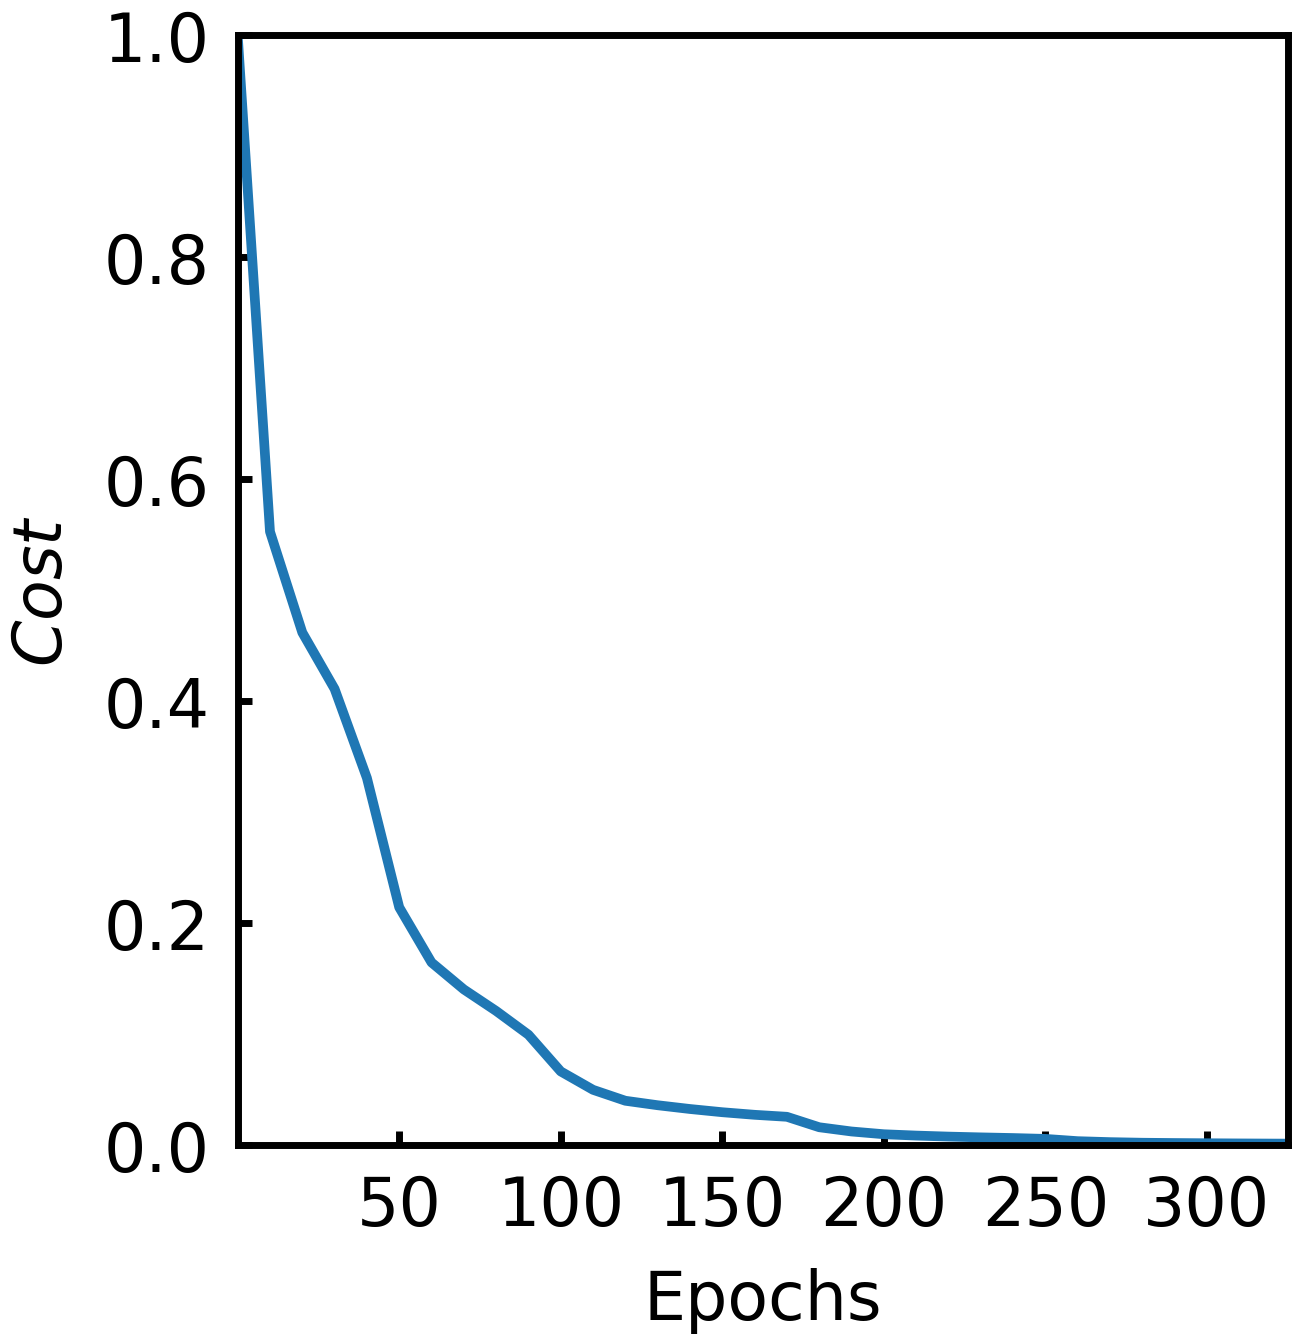

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
plt.style.use("manuscript.mplstyle")
import numpy as np
import graphParams
import os

kV = 10
V0 = 1
s0Vals = [5.2,5.8]
x0 = 0
x1 = 325
y0 = 0
y1 = 1
xticks = [50*i for i in range(1,100)]
yticks = [0.2*i for i in range(100)]
xlabel = r"Epochs"
ylabel = r"$Cost$"
fig = plt.figure()
ax = fig.add_axes([
    graphParams.leftMargin,
    graphParams.bottomMargin,
    graphParams.width,
    graphParams.height])
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((0,0))
it = []
cst = []
for iter,cost in cost_vals.items():
    it.append(iter)
    cst.append(cost)
print(cst)
ax.plot(it,cst/cst[0])
ax.set_xticks(xticks)
ax.set_yticks(yticks)
# ax.yaxis.set_major_formatter(formatter)

ax.set_xlim(x0,x1)
ax.set_ylim(y0,y1)
ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
    # ax.set_title(r"$P = {:.2f}$".format(p))
fig.savefig("cheshire/APS/cost.png",transparent=True)

In [49]:

import imageio
import numpy as np
from PIL import Image, ImageDraw

# Parameters
width, height = 400, 70  # Size of the image
bar_height = 40  # Height of the progress bar
frames = 46 # Number of frames (smoothness)
duration = 10 # Total duration in seconds
frame_duration = duration / frames  # Time per frame
print(frame_duration)
gif_frames = []

for i in range(frames + 1):
    img = Image.new("RGBA", (width, height), "white")
    draw = ImageDraw.Draw(img, "RGBA")
    
    # Background Bar
    draw.rectangle([50, (height - bar_height) // 2, width - 50, (height + bar_height) // 2], outline="black", width=3)
    
    # Progress Fill with Reduced Opacity
    progress = (width - 100) * (i / frames)
    draw.rectangle([50, (height - bar_height) // 2, 50 + progress, (height + bar_height) // 2], fill=(135, 110, 204))  # Blue with 50% opacity
    
    gif_frames.append(np.array(img.convert("RGB")))

# Save GIF
imageio.mimsave("progress_bar_training.gif", gif_frames, duration=frame_duration, loop = 0)

0.21739130434782608
